# This file serves to demonstrate the differences of the hysteresis metrics

author: Eike E. Köhn ......
date: July 29, 2025 ......
instructions: can be run with environment "conda env:pangeo-meso-2024.01.22" on spirit1

## Import packages

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())
misc_params = Params.additional_misc_params()

Loading packages...


## Import the hysteresis software directly for easier use

In [2]:
sys.path.insert(0,'/home/ekoehn/software/')
#import hysteresis # import the package
from hysteresis import hyst_areas as ha # import the submodule hyst_areas
from hysteresis import loop_metrics as lm # import the submodule loop_metrics

## Decide if figures are to be saved (and if so the directory)

In [3]:
savefigs = True
plot_dir = Plotter._get_plot_dir('standard')

## Generate dummy data

In [4]:
def generate_dummy_data():
    x2 = np.linspace(0,np.pi/2,140)
    n2 = np.size(x2)
    x = np.concatenate([x2,x2[::-1]])
    y1 = np.sin(x)*10 
    y2 = np.sin(x)*5
    y1[n2+5:] = y1[n2:-5]
    y2[n2+5:] = y2[n2:-5]
    pic = 284.7
    x = (((x/np.pi*2)*3)+1) * pic #x*1000/np.pi*2 
    
    h1 = ha.calc_hysteresis_area_1D(x, y1, nsteps=100, normalizer='min_max_diff_full_cycle', return_interpolated_vectors=False)
    h2 = ha.calc_hysteresis_area_1D(x, y2, nsteps=100, normalizer='min_max_diff_full_cycle', return_interpolated_vectors=False)
    return x,n2,y1,y2,h1,h2,pic

x,n2,y1,y2,h1,h2,pic = generate_dummy_data()

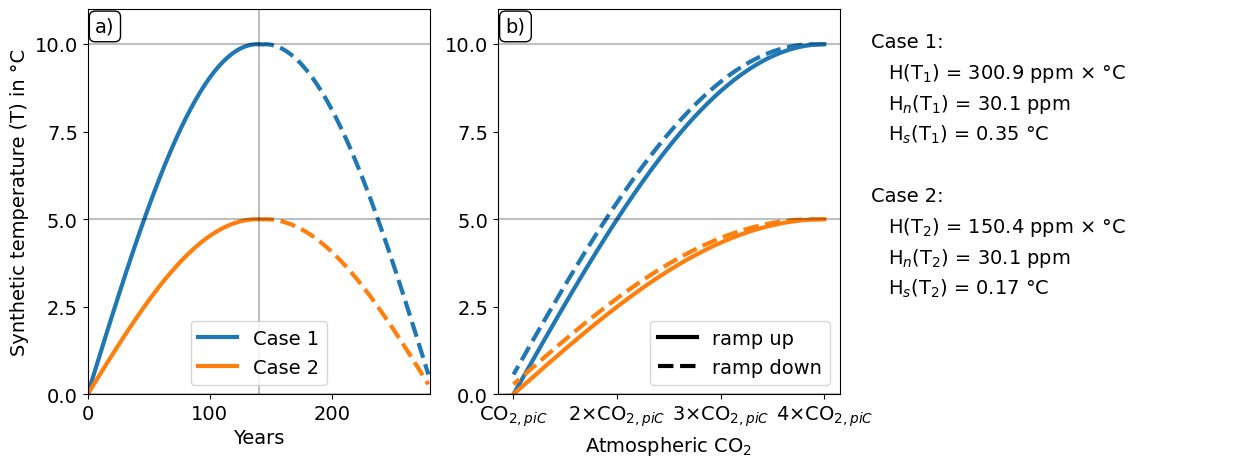

In [15]:
def plot_dummy_data_example():
    fontsize=14
    plt.rcParams['font.size']=fontsize
    fig,ax = plt.subplots(1,3,figsize=(15,5))
    ax[0].plot(np.arange(np.size(x))[:n2],y1[:n2],'-',color='C0',linewidth=3,label='Case 1')
    ax[0].plot(np.arange(np.size(x))[n2:],y1[n2:],'--',color='C0',linewidth=3)
    ax[0].plot(np.arange(np.size(x))[:n2],y2[:n2],'-',color='C1',linewidth=3,label='Case 2')
    ax[0].plot(np.arange(np.size(x))[n2:],y2[n2:],'--',color='C1',linewidth=3)
    ax[0].axvline(n2,color='k',alpha=0.25)
    ax[0].axhline([0],color='k',alpha=0.25)
    ax[0].axhline([5],color='k',alpha=0.25)
    ax[0].axhline([10],color='k',alpha=0.25)
    ax[0].set_ylim([0,11])
    ax[0].set_xlim([0,np.size(x)])
    ax[0].set_yticks([0,2.5,5,7.5,10])
    ax[0].set_xlabel('Years')
    ax[0].set_ylabel('Synthetic temperature (T) in °C')# variable (e.g., SST in °C)')
    ax[0].legend(loc='lower center')
    ax[0].text(0.022,0.98,'a)',ha='left',va='top',bbox={'boxstyle':'round','fc':'w'},transform=ax[0].transAxes)
    
    ax[1].plot(x[:n2],y1[:n2],'-',color='C0',linewidth=3)
    ax[1].plot(x[n2:],y1[n2:],'--',color='C0',linewidth=3)
    ax[1].plot(x[:n2],y2[:n2],'-',color='C1',linewidth=3)
    ax[1].plot(x[n2:],y2[n2:],'--',color='C1',linewidth=3)
    ax[1].plot(x[:n2],y1[:n2]+5000,'-',color='k',linewidth=3,label='ramp up')
    ax[1].plot(x[n2:],y1[n2:]+5000,'--',color='k',linewidth=3,label='ramp down')
    ax[1].axhline([0],color='k',alpha=0.25)
    ax[1].axhline([5],color='k',alpha=0.25)
    ax[1].axhline([10],color='k',alpha=0.25)
    ax[1].set_xticks([pic,2*pic,3*pic,4*pic])
    ax[1].set_xticklabels(['CO$_{2,piC}$',r'2$\times$CO$_{2,piC}$',r'3$\times$CO$_{2,piC}$',r'4$\times$CO$_{2,piC}$'])
    ax[1].set_ylim([0,11])
    ax[1].set_yticks([0,2.5,5,7.5,10])
    ax[1].legend(loc='lower right')
    ax[1].set_xlabel(r'Atmospheric CO$_2$')
    ax[1].text(0.022,0.98,'b)',ha='left',va='top',bbox={'boxstyle':'round','fc':'w'},transform=ax[1].transAxes)
    
    #ax[2].set_visible(False)
    ax[2].text(-.11,0.9,'Case 1:',transform=ax[2].transAxes)
    ax[2].text(-.06,0.82,f'H(T$_1$) = {h1[0]:.1f} ppm '+r'$\times$'+' °C',transform=ax[2].transAxes)
    ax[2].text(-.06,0.74,f'H$_n$(T$_1$) = {h1[2]:.1f} ppm',transform=ax[2].transAxes)
    ax[2].text(-.06,0.66,f'H$_s$(T$_1$) = {h1[1]:.2f} °C',transform=ax[2].transAxes)

    
    ax[2].text(-.11,0.5,'Case 2:',transform=ax[2].transAxes)
    ax[2].text(-.06,0.42,f'H(T$_2$) = {h2[0]:.1f} ppm '+r'$\times$'+' °C',transform=ax[2].transAxes)
    ax[2].text(-.06,0.34,f'H$_n$(T$_2$) = {h2[2]:.1f} ppm',transform=ax[2].transAxes)
    ax[2].text(-.06,0.26,f'H$_s$(T$_2$) = {h2[1]:.2f} °C',transform=ax[2].transAxes)

    
    ax[2].spines[['right', 'top','left','bottom']].set_visible(False)
    ax[2].set_xticks([])
    ax[2].set_yticks([])
    #plt.savefig(f'plots_for_egu2025/sketch_for_hysteresis_areas.png',dpi=300,transparent=True)
    return fig, ax 

fig, ax = plot_dummy_data_example()
if savefigs == True:
    fig.savefig(f'{plot_dir}/sketch_for_hysteresis_areas.png',dpi=300,transparent=True)
